# Laboratorio 2 - Deep Learning
## Modelos LSTM para series de tiempo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Ejercicio 1

## 1.1
### Carga de las series a analizar

Se utilizarán dos series únicamente: la serie del total de visitantes y de entrada vía aérea.

In [2]:
# Dataset de total
train = pd.read_csv(
    "total_train.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "total_test.csv",
    index_col=0,
    parse_dates=True
)

train = train["viajeros"]
test = test["viajeros"]


# Dataset de aérea
train2 = pd.read_csv(
    "aerea_train.csv",
    index_col=0,
    parse_dates=True
)

test2 = pd.read_csv(
    "aerea_test.csv",
    index_col=0,
    parse_dates=True
)

train2 = train2["viajeros"]
test2 = test2["viajeros"]

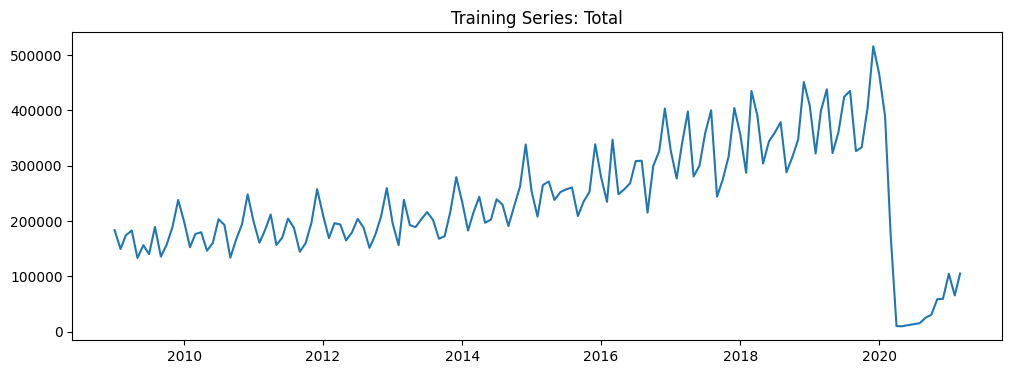

In [3]:
plt.figure(figsize=(12,4))
plt.plot(train)
plt.title("Training Series: Total")
plt.show()

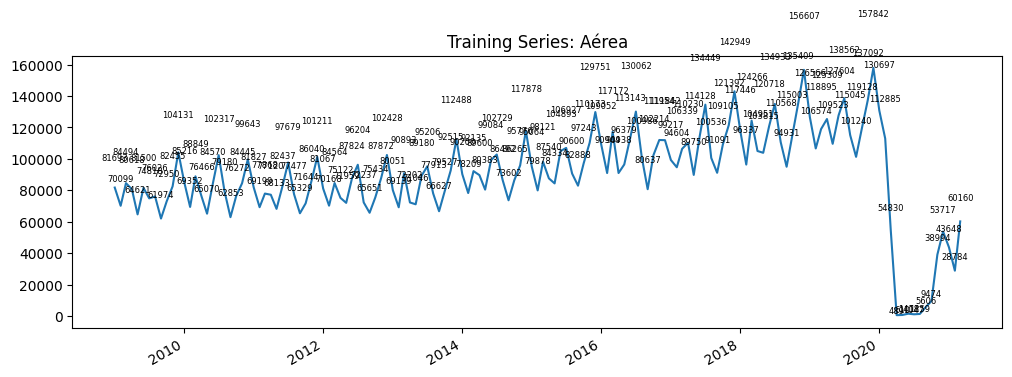

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(train2)

# ---- NEW CODE TO ADD NUMBERS ----
# Loop through the index (dates) and values of your series
for date, value in train2.items():
    # Adjust the positioning (value + offset) so text doesn't sit on the line
    # For integers, convert to string. For decimals, use f"{value:.1f}" to round.
    plt.text(date, value + (value * 0.2), str(int(value)), 
             ha='center', va='bottom', fontsize=6, color='black')
# ---------------------------------

plt.title("Training Series: Aérea")
plt.gcf().autofmt_xdate() # Rotates the dates so they don't overlap
plt.show()

### Normalización

Reducir la escala de los datos para facilitar el aprendizaje de la red neuronal

In [5]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))

scaler_aerea = MinMaxScaler()
train2_scaled = scaler_aerea.fit_transform(train2.values.reshape(-1,1))
test2_scaled = scaler_aerea.transform(test2.values.reshape(-1,1))

### Ventanas de tiempo
Se utilizarán los últimos 12 meses para predecir el siguiente mes

In [6]:
LOOK_BACK = 12

def create_dataset(data, look_back):

    X = []
    y = []

    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])

    return np.array(X), np.array(y)

In [7]:
X_train, y_train = create_dataset(train_scaled, LOOK_BACK)
X_test, y_test = create_dataset(test_scaled, LOOK_BACK)

X_train2, y_train2 = create_dataset(train2_scaled, LOOK_BACK)
X_test2, y_test2 = create_dataset(test2_scaled, LOOK_BACK)

In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Aérea
X_train2 = torch.tensor(X_train2, dtype=torch.float32)
y_train2 = torch.tensor(y_train2, dtype=torch.float32)
X_test2 = torch.tensor(X_test2, dtype=torch.float32)
y_test2 = torch.tensor(y_test2, dtype=torch.float32)    

### Carga de datos

In [9]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=False
)

train_loader2 = DataLoader(
    TensorDataset(X_train2, y_train2),
    batch_size=8,
    shuffle=False
)

### Clase de LSTM para los 2 modelos

In [10]:
class LSTMModel(nn.Module):

    def __init__(self, hidden):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            batch_first=True
        )

        self.fc = nn.Linear(hidden,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

### Función de entrenamiento

In [11]:
def train_model(model, train_loader, epochs):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0

        for X, y in train_loader:

            optimizer.zero_grad()

            pred = model(X)

            loss = criterion(pred, y)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return losses

## 1.2 Modelos LSTM

#### Modelo 1

In [12]:
model1 = LSTMModel(hidden=32)

loss1 = train_model(
    model1,
    train_loader,
    epochs=50
)

# SERIE AÉREA
model1_air = LSTMModel(hidden=32)

loss1_air = train_model(
    model1_air,
    train_loader2,
    epochs=50
)      

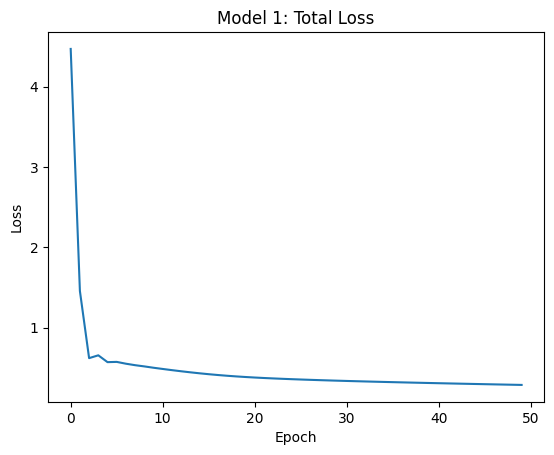

In [13]:
plt.plot(loss1)
plt.title("Model 1: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

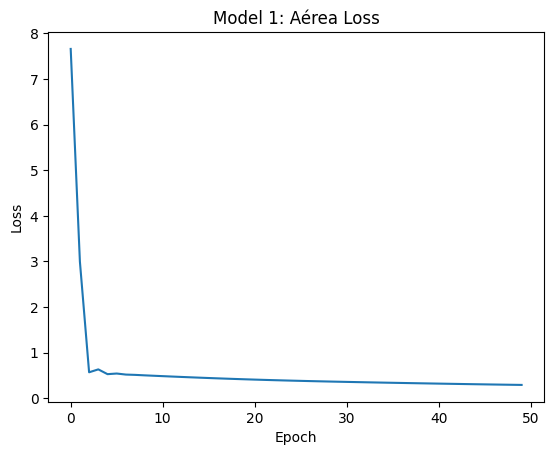

In [14]:
plt.plot(loss1_air)
plt.title("Model 1: Aérea Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Ambos modelos parecen reducir su error de predicción considerablemente conforme la cantidad de veces que han revisado el dataset de training ha aumentado.

#### Modelo 2

Incluye cambio de parámetros en hidden units y epochs.

In [15]:
model2 = LSTMModel(hidden=64)

loss2 = train_model(
    model2,
    train_loader,
    epochs=100
)

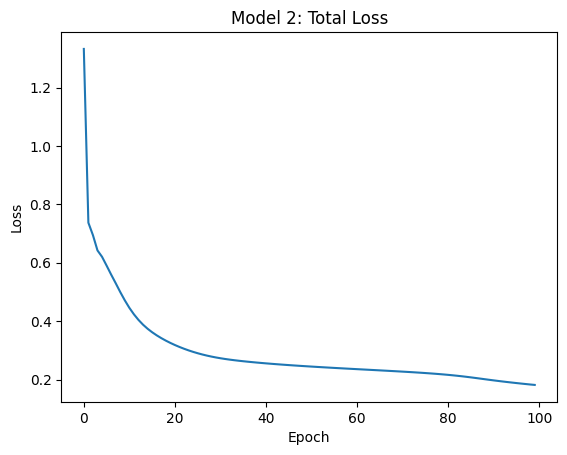

In [16]:
plt.plot(loss2)
plt.title("Model 2: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [17]:
model2_air = LSTMModel(hidden=64)

loss2_air = train_model(
    model2_air, 
    train_loader2,
    epochs=100
)

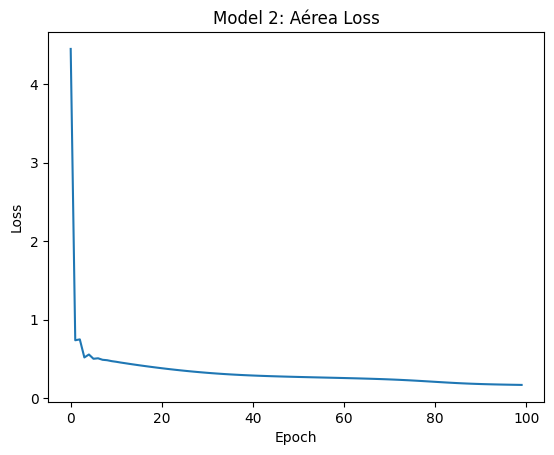

In [18]:
plt.plot(loss2_air)
plt.title("Model 2: Aérea Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 1.3 Predicciones
### Función de predicción

In [19]:
def predict(model,X, scaler):

    model.eval()

    with torch.no_grad():

        pred = model(X).numpy()

    return scaler.inverse_transform(pred)

pred1 = predict(model1, X_test, scaler)
pred2 = predict(model2, X_test, scaler)

real = scaler.inverse_transform(y_test.numpy())

# Segunda serie: Aérea

pred1_air = predict(model1_air, X_test2, scaler_aerea)
pred2_air = predict(model2_air, X_test2, scaler_aerea)

#regresar a la escala original
real_air = scaler_aerea.inverse_transform(y_test2.numpy())

In [20]:
## METRICAS
def evaluate(real,pred):

    rmse = np.sqrt(mean_squared_error(real,pred))
    mae = mean_absolute_error(real,pred)

    mape = np.mean(
        np.abs((real-pred)/real)
    )*100

    return rmse,mae,mape

rmse1,mae1,mape1 = evaluate(real,pred1)
rmse2,mae2,mape2 = evaluate(real,pred2)

# Métricas Aérea

rmse1_air,mae1_air,mape1_air = evaluate(real_air,pred1_air)
rmse2_air,mae2_air,mape2_air = evaluate(real_air,pred2_air)

results = pd.DataFrame({

    "Model":[
        "LSTM 1",
        "LSTM 2",
        "LSTM 1",
        "LSTM 2"
    ],

    "Series":[
        "Total",
        "Total",
        "Aérea",
        "Aérea"
    ],

    "RMSE":[
        rmse1,
        rmse2,
        rmse1_air,
        rmse2_air
    ],

    "MAE":[
        mae1,
        mae2,
        mae1_air,
        mae2_air
    ],

    "MAPE":[
        mape1,
        mape2,
        mape1_air,
        mape2_air
    ]
})

results

,Model,Series,RMSE,MAE,MAPE
0,LSTM 1,Total,63824.110303,49021.707031,15.870608
1,LSTM 2,Total,58218.257480,45795.148438,15.149678
2,LSTM 1,Aérea,18349.073001,15175.522461,16.140545
3,LSTM 2,Aérea,17382.636854,12745.834961,13.595861


### Predicciones: visualización

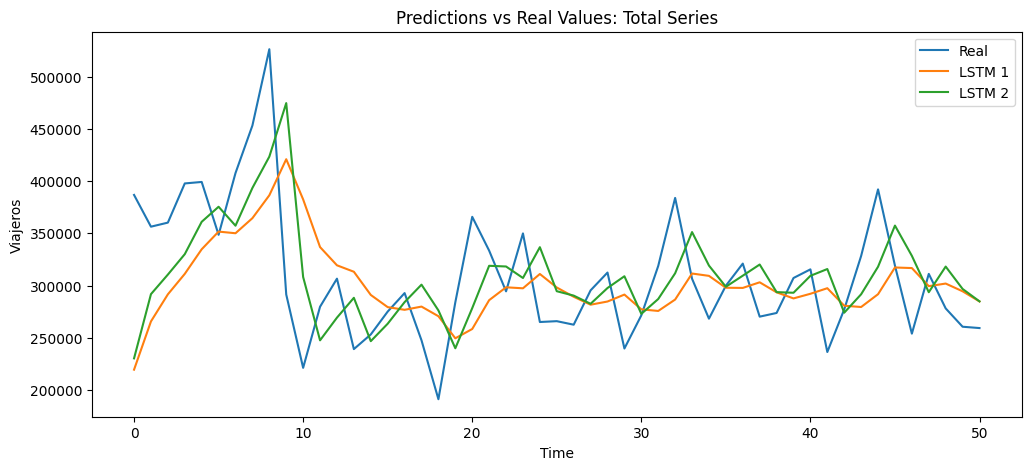

In [21]:
plt.figure(figsize=(12,5))

plt.title("Predictions vs Real Values: Total Series")

plt.xlabel("Time")
plt.ylabel("Viajeros")


plt.plot(real,label="Real")

plt.plot(pred1,label="LSTM 1")

plt.plot(pred2,label="LSTM 2")

plt.legend()

plt.show()

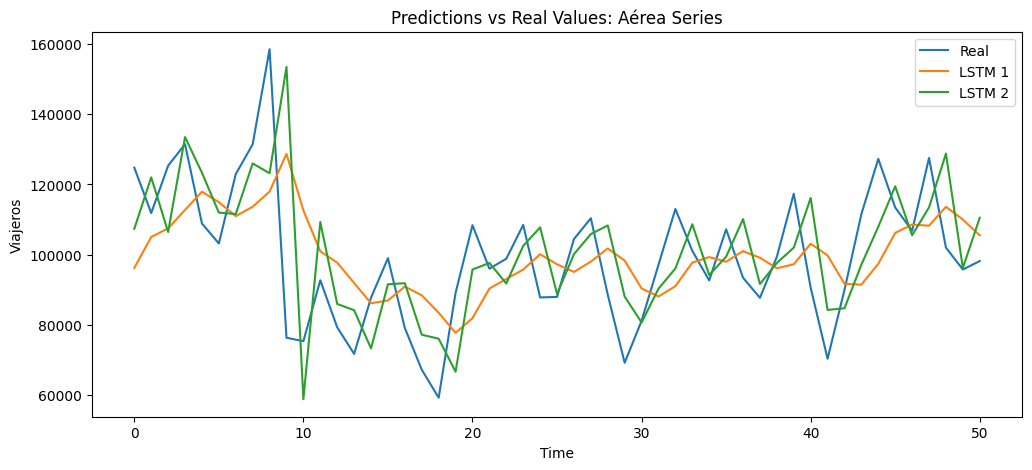

In [22]:
plt.figure(figsize=(12,5))

plt.title("Predictions vs Real Values: Aérea Series")

plt.xlabel("Time")
plt.ylabel("Viajeros")


plt.plot(real_air,label="Real")

plt.plot(pred1_air,label="LSTM 1")

plt.plot(pred2_air,label="LSTM 2")

plt.legend()

plt.show()

In [23]:
best = results.loc[results.groupby("Series")["RMSE"].idxmin()]

print(best)

    Model Series          RMSE           MAE       MAPE
3  LSTM 2  Aérea  17382.636854  12745.834961  13.595861
1  LSTM 2  Total  58218.257480  45795.148438  15.149678


Es evidente que el modelo 2 presentó mayor precisión por la escala de su error medio.

In [24]:
comparison = pd.DataFrame({

    "Model":[
        "Holt-Winters",
        "LSTM 1",
        "LSTM 2",
        "Holt-Winters",
        "LSTM 1",
        "LSTM 2"
    ],

    "Series":[
        "Total",
        "Total",
        "Total",
        "Aérea",
        "Aérea",
        "Aérea"
    ],

    "RMSE":[
        168288.8,     
        rmse1,
        rmse2,
        29846.3,
        rmse1_air,  
        rmse2_air
    ],

    "MAE":[
        148782.5,     
        mae1,
        mae2,
        24619.3,
        mae1_air,
        mae2_air
    ],

    "MAPE":[
        48.8,     
        mape1,
        mape2,
        24.3,
        mape1_air,
        mape2_air
    ]



})

comparison

,Model,Series,RMSE,MAE,MAPE
0,Holt-Winters,Total,168288.800000,148782.500000,48.800000
1,LSTM 1,Total,63824.110303,49021.707031,15.870608
2,LSTM 2,Total,58218.257480,45795.148438,15.149678
3,Holt-Winters,Aérea,29846.300000,24619.300000,24.300000
4,LSTM 1,Aérea,18349.073001,15175.522461,16.140545
5,LSTM 2,Aérea,17382.636854,12745.834961,13.595861


A comparación del modelo de Holt-Winters, ambos modelos de Deep Learning evidencian un mayor rendimiento para hacer predicciones. Ahora, entre dichos modelos, el segundo resultó ser el mejor candidato porque cuenta con un mayor número de neuronas y más épocas de entrenamiento, lo que le permite aprender patrones temporales más complejos, como la tendencia y la estacionalidad presentes en la serie de viajeros. 

En este caso el Modelo 2, que tiene arquitectura de mayor complejidad fue necesaria para generalizar la predicción.

# **Ejercicio 2**

**2.1 ¿Qué es catch22 y por qué es importante?**

catch22 surge como una versión simplificada de **hctsa** (*Highly Comparative Time-Series Analysis*), una metodología que analiza series de tiempo calculando miles de métricas estadísticas, como autocorrelación, entropía, medidas de no linealidad y características de la distribución. El objetivo de hctsa es describir una serie de tiempo de la manera más completa posible. Sin embargo, este enfoque requiere un alto costo computacional y muchas de las métricas obtenidas aportan información muy similar entre sí.

Para solucionar este problema, **catch22** (Fulcher, Little & Jones, 2013) selecciona únicamente **22 características representativas** que conservan gran parte de la capacidad para diferenciar distintos tipos de series de tiempo, pero evitando la redundancia y reduciendo considerablemente el tiempo de cálculo.

La principal ventaja de catch22 es que permite analizar, comparar y clasificar series de tiempo de forma eficiente y con un conjunto de características estandarizado, sin depender de un conocimiento profundo del dominio de aplicación. En contextos como el sector bancario, este enfoque resulta útil para identificar patrones en el comportamiento de los clientes, detectar anomalías en las transacciones y apoyar la selección automática del modelo de pronóstico más adecuado según las propiedades estadísticas de cada serie.

**2.2 – 2.4 Extracción de características catch22, construcción de la matriz y estandarización**

Se utilizan las 7 series construidas en el Laboratorio 1 (conjunto de **entrenamiento**, igual que en el resto del análisis del laboratorio anterior): Total, Vía Aérea, Vía Terrestre, Vía Marítima, Región América del Centro, Región América del Norte y Región Europa.

In [25]:
import pycatch22
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Carga de las 7 series de entrenamiento construidas en el Laboratorio 1
archivos_series = {
    "Total": "total_train.csv",
    "Vía Aérea": "aerea_train.csv",
    "Vía Terrestre": "terrestre_train.csv",
    "Vía Marítima": "maritima_train.csv",
    "Región América Del Centro": "region_america_del_centro_train.csv",
    "Región América Del Norte": "region_america_del_norte_train.csv",
    "Región Europa": "region_europa_train.csv",
}

series_train = {
    nombre: pd.read_csv(archivo, index_col=0, parse_dates=True)["viajeros"]
    for nombre, archivo in archivos_series.items()
}

for nombre, s in series_train.items():
    print(f"{nombre:30s} N={len(s):4d}  {s.index.min():%Y-%m} a {s.index.max():%Y-%m}")

Total                          N= 147  2009-01 a 2021-03
Vía Aérea                      N= 147  2009-01 a 2021-03
Vía Terrestre                  N= 147  2009-01 a 2021-03
Vía Marítima                   N= 135  2009-01 a 2020-03
Región América Del Centro      N= 147  2009-01 a 2021-03
Región América Del Norte       N= 147  2009-01 a 2021-03
Región Europa                  N= 147  2009-01 a 2021-03


In [26]:
# 2.2 Extracción de las 22 características de catch22 para cada serie
filas = []
nombres = []
for nombre, s in series_train.items():
    resultado = pycatch22.catch22_all(s.values.tolist(), short_names=True)
    filas.append(dict(zip(resultado["short_names"], resultado["values"])))
    nombres.append(nombre)

# 2.3 Matriz: cada fila una serie, cada columna una característica de catch22
matriz_catch22 = pd.DataFrame(filas, index=nombres)
print(f"Matriz catch22: {matriz_catch22.shape[0]} series x {matriz_catch22.shape[1]} características")
matriz_catch22.round(3)

Matriz catch22: 7 series x 22 características


,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,whiten_timescale,outlier_timing_pos,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error
Total,-0.741,-0.493,8.322,10,0.457,-0.108,0.932,42.0,0.062,11,...,0.033,0.619,0.891,0.823,6.0,1.780,0.850,0.775,0.147,0.616
Vía Aérea,-0.339,-0.072,6.170,10,0.285,-0.102,0.945,42.0,0.063,11,...,0.143,0.605,0.891,0.788,5.0,1.956,0.150,0.800,0.172,0.692
Vía Terrestre,-0.434,-0.671,8.864,3,0.528,-0.098,0.904,42.0,0.062,3,...,0.029,0.633,0.871,0.813,6.0,1.783,0.850,0.775,0.098,0.613
Vía Marítima,-0.846,-1.064,1.489,6,0.091,-0.100,0.940,9.0,0.021,11,...,0.250,0.615,-0.015,0.636,5.0,2.059,0.179,0.846,0.540,1.042
Región América Del Centro,-0.495,-0.743,8.689,10,0.525,-0.085,0.890,42.0,0.062,3,...,0.029,0.646,0.878,0.828,6.0,1.752,0.850,0.800,0.123,0.600
Región América Del Norte,-0.327,-0.082,5.101,3,0.223,-0.117,0.959,12.0,0.026,3,...,0.100,0.401,0.891,0.637,5.0,2.112,0.825,0.700,0.270,0.855
Región Europa,0.487,0.270,4.014,7,0.317,-0.128,0.911,11.0,0.030,11,...,0.071,0.497,0.905,0.710,6.0,2.052,0.150,0.700,0.295,0.803


In [27]:
# 2.4 Estandarización de las características antes de cualquier análisis comparativo
scaler_c22 = StandardScaler()
X_std = scaler_c22.fit_transform(matriz_catch22.values)
matriz_std = pd.DataFrame(X_std, index=matriz_catch22.index, columns=matriz_catch22.columns)
matriz_std.round(2)

,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,whiten_timescale,outlier_timing_pos,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error
Total,-0.89,-0.20,0.87,1.02,0.73,-0.20,0.24,0.86,0.85,0.87,...,-0.80,0.54,0.42,0.94,0.87,-1.04,0.88,0.08,-0.62,-0.85
Vía Aérea,0.11,0.78,0.03,1.02,-0.40,0.27,0.84,0.86,0.89,0.87,...,0.66,0.38,0.42,0.51,-1.15,0.20,-1.18,0.58,-0.45,-0.36
Vía Terrestre,-0.12,-0.61,1.08,-1.37,1.19,0.57,-0.95,0.86,0.85,-1.15,...,-0.87,0.70,0.35,0.82,0.87,-1.02,0.88,0.08,-0.96,-0.88
Vía Marítima,-1.15,-1.52,-1.80,-0.34,-1.68,0.40,0.63,-1.26,-1.39,0.87,...,2.08,0.49,-2.45,-1.41,-1.15,0.93,-1.10,1.51,2.15,1.95
Región América Del Centro,-0.27,-0.78,1.01,1.02,1.17,1.59,-1.55,0.86,0.85,-1.15,...,-0.86,0.87,0.38,1.01,0.87,-1.24,0.88,0.58,-0.79,-0.96
Región América Del Norte,0.15,0.76,-0.39,-1.37,-0.81,-0.86,1.44,-1.07,-1.14,-1.15,...,0.08,-2.06,0.42,-1.39,-1.15,1.30,0.81,-1.42,0.25,0.72
Región Europa,2.18,1.57,-0.81,0.00,-0.19,-1.77,-0.65,-1.13,-0.90,0.87,...,-0.30,-0.92,0.46,-0.48,0.87,0.88,-1.18,-1.42,0.42,0.38


**2.5 Análisis exploratorio de la matriz catch22**

### Análisis de Componentes Principales (PCA)

Varianza explicada por componente: [0.525 0.22  0.13  0.076 0.028]
Varianza acumulada: [0.525 0.745 0.874 0.95  0.978]


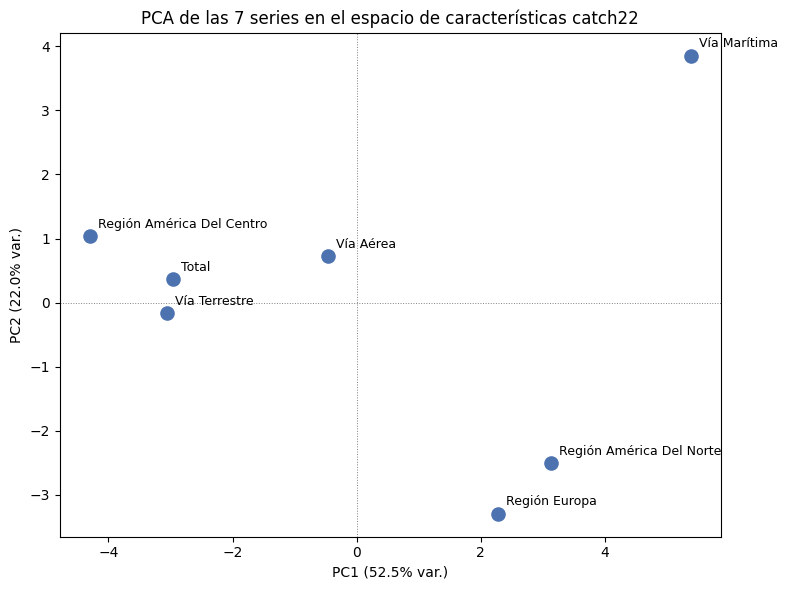


Características con mayor peso en PC1:
 forecast_error       0.286
acf_timescale       -0.285
centroid_freq       -0.284
ami2                -0.280
entropy_pairs        0.278
transition_matrix   -0.276
dtype: float64

Características con mayor peso en PC2:
 dfa                   0.447
mode_10              -0.390
mode_5               -0.370
outlier_timing_pos    0.336
trev                  0.332
outlier_timing_neg   -0.332
dtype: float64


In [28]:
pca = PCA(n_components=min(5, X_std.shape[0]-1))
pcs = pca.fit_transform(X_std)

print("Varianza explicada por componente:", pca.explained_variance_ratio_.round(3))
print("Varianza acumulada:", pca.explained_variance_ratio_.cumsum().round(3))

pcs_df = pd.DataFrame(pcs[:, :3], index=matriz_std.index, columns=["PC1", "PC2", "PC3"])

plt.figure(figsize=(8, 6))
plt.scatter(pcs_df["PC1"], pcs_df["PC2"], s=90, color="#4C72B0")
for nombre, row in pcs_df.iterrows():
    plt.annotate(nombre, (row["PC1"], row["PC2"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.axhline(0, color="gray", lw=0.7, ls=":")
plt.axvline(0, color="gray", lw=0.7, ls=":")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("PCA de las 7 series en el espacio de características catch22")
plt.tight_layout()
plt.show()

loadings_pc1 = pd.Series(pca.components_[0], index=matriz_std.columns).sort_values(key=abs, ascending=False)
loadings_pc2 = pd.Series(pca.components_[1], index=matriz_std.columns).sort_values(key=abs, ascending=False)
print("\nCaracterísticas con mayor peso en PC1:\n", loadings_pc1.head(6).round(3))
print("\nCaracterísticas con mayor peso en PC2:\n", loadings_pc2.head(6).round(3))

### Clustering

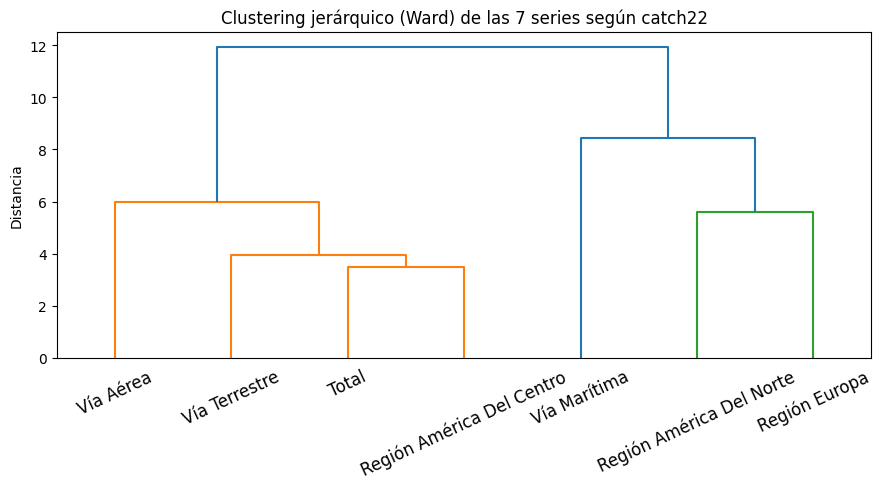

In [29]:
Z = linkage(X_std, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(Z, labels=matriz_std.index.tolist(), leaf_rotation=25)
plt.title("Clustering jerárquico (Ward) de las 7 series según catch22")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

### Mapa de calor (Heatmap) de las características

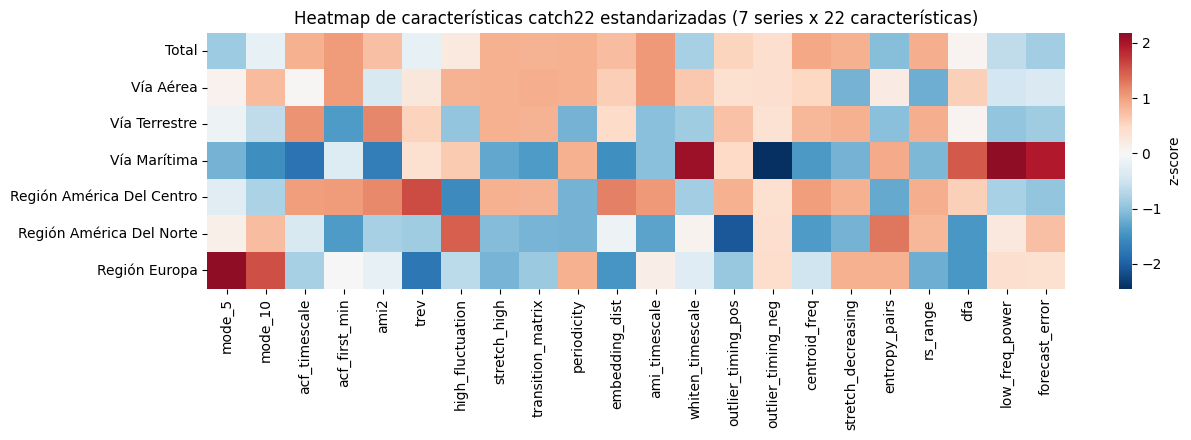

In [30]:
plt.figure(figsize=(13, 4.5))
sns.heatmap(matriz_std, cmap="RdBu_r", center=0, cbar_kws={"label": "z-score"})
plt.title("Heatmap de características catch22 estandarizadas (7 series x 22 características)")
plt.tight_layout()
plt.show()

### Matriz de correlaciones entre características

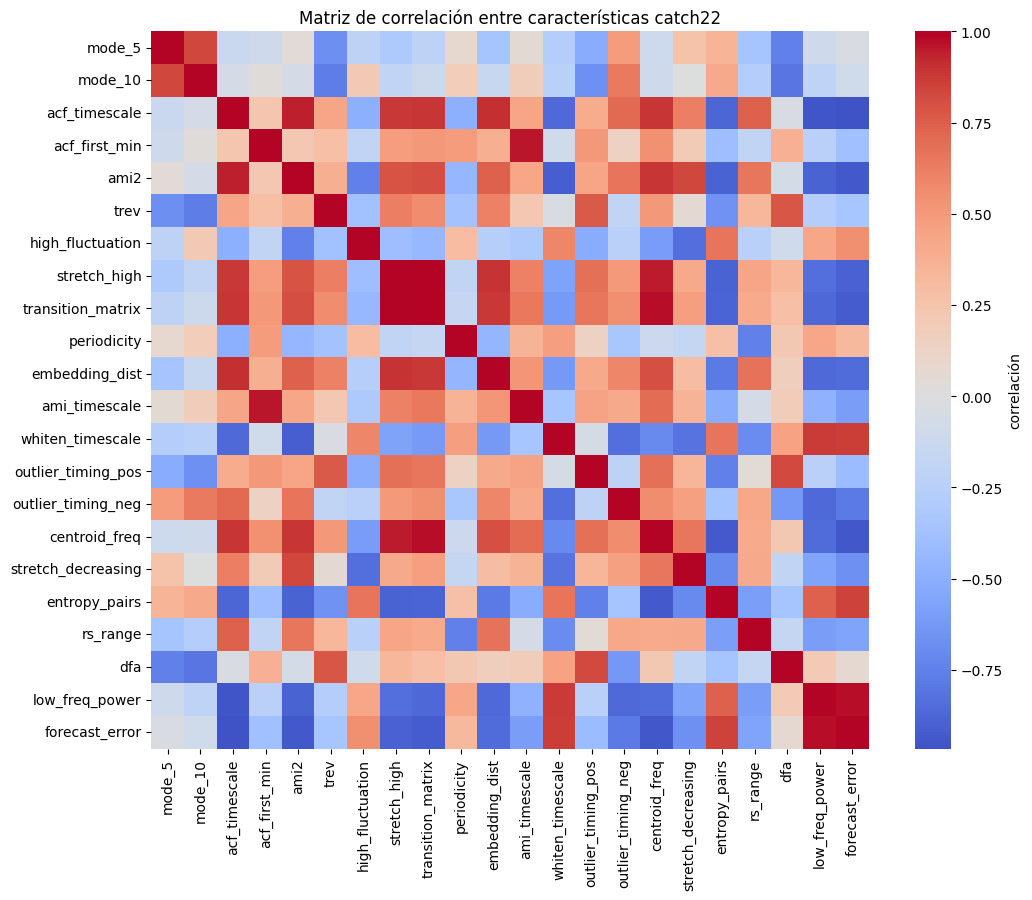

In [31]:
corr_features = matriz_std.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_features, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "correlación"})
plt.title("Matriz de correlación entre características catch22")
plt.tight_layout()
plt.show()

### Mapa de distancias entre series

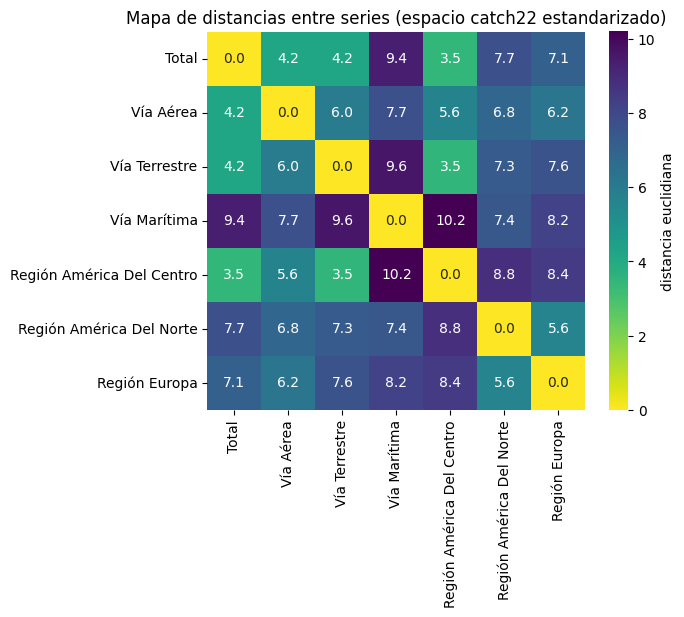

,Total,Vía Aérea,Vía Terrestre,Vía Marítima,Región América Del Centro,Región América Del Norte,Región Europa
Total,0.00,4.16,4.16,9.35,3.48,7.72,7.11
Vía Aérea,4.16,0.00,6.01,7.71,5.63,6.81,6.22
Vía Terrestre,4.16,6.01,0.00,9.62,3.51,7.29,7.58
Vía Marítima,9.35,7.71,9.62,0.00,10.19,7.43,8.19
Región América Del Centro,3.48,5.63,3.51,10.19,0.00,8.82,8.41
Región América Del Norte,7.72,6.81,7.29,7.43,8.82,0.00,5.58
Región Europa,7.11,6.22,7.58,8.19,8.41,5.58,0.00


In [32]:
dist = pdist(X_std, metric="euclidean")
matriz_distancias = pd.DataFrame(squareform(dist), index=matriz_std.index, columns=matriz_std.index)

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_distancias, cmap="viridis_r", annot=True, fmt=".1f", square=True,
            cbar_kws={"label": "distancia euclidiana"})
plt.title("Mapa de distancias entre series (espacio catch22 estandarizado)")
plt.tight_layout()
plt.show()

matriz_distancias.round(2)

**2.6 Análisis e interpretación**

**2.7 ¿Cuáles series presentan comportamientos más similares?**

De acuerdo con el **dendrograma** y el **Análisis de Componentes Principales (PCA)**, las series **Total**, **Vía Terrestre** y **Región América del Centro** son las que presentan mayor similitud. En el análisis de agrupamiento jerárquico son las primeras en unirse, con las distancias más bajas de toda la matriz (Total–Región Centro = 3.48 y este grupo con Vía Terrestre = 3.96). Además, en el plano del PCA se ubican en la misma zona, caracterizada por valores muy negativos del primer componente principal (PC1). Posteriormente, **Vía Aérea** se incorpora a este mismo grupo, aunque con una distancia mayor (5.97), lo que indica una similitud menor.

Estos resultados son consistentes con la composición del conjunto de datos. De acuerdo con el informe del Laboratorio 1, aproximadamente el **73 %** de los viajeros proviene de **Centroamérica** y alrededor del **60 %** ingresa por **vía terrestre**. Por ello, las series **Total**, **Vía Terrestre** y **Región América del Centro** representan, en gran medida, el mismo flujo de turistas desde diferentes perspectivas. Lo relevante es que **catch22** identifica esta relación únicamente a partir de las características estadísticas de las series de tiempo, sin utilizar información previa sobre la distribución de los viajeros.

**2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**

El **primer componente principal**, que explica el **52.5 % de la variabilidad**, está influenciado principalmente por las características `forecast_error`, `acf_timescale`, `centroid_freq`, `ami2`, `entropy_pairs` y `transition_matrix`. Estas variables describen aspectos relacionados con la **capacidad de predicción** y la **estructura de autocorrelación** de las series de tiempo, más que con su magnitud o nivel.

Por su parte, el **segundo componente principal** aporta un **22.0 % adicional** de la varianza, alcanzando un **74.5 % acumulado**. Este componente está determinado principalmente por `dfa`, `mode_10`, `mode_5` y `outlier_timing_pos/neg`, características que reflejan el **comportamiento de las fluctuaciones a largo plazo** y la **presencia de valores atípicos** en las series.

En conjunto, estos dos componentes resumen cerca de las tres cuartas partes de la información contenida en las siete series analizadas, lo que indica que la mayor parte de sus diferencias puede explicarse mediante estas dos dimensiones principales.

**2.9 ¿Existen grupos naturales de series? ¿Qué tienen en común?**

Sí, se observan dos grupos claros:

- **Grupo A — flujo principal y comportamiento estable:** Está conformado por **Total**, **Vía Terrestre**, **Región América del Centro** y, con una similitud ligeramente menor, **Vía Aérea**. Estas series presentan errores de pronóstico relativamente bajos (`forecast_error` entre 0.60 y 0.69), además de contar con un mayor número de observaciones (N = 147), lo que refleja patrones de tendencia y estacionalidad bien definidos y más fáciles de modelar.

- **Grupo B — turismo de larga distancia y mayor variabilidad:** Incluye **Vía Marítima**, **Región América del Norte** y **Región Europa**. Estas series se caracterizan por tener errores de pronóstico más elevados (`forecast_error` entre 0.80 y 1.04), así como una mayor presencia de valores atípicos y cambios de largo plazo, representados por métricas como `dfa` y `outlier_timing`, lo que hace que su comportamiento sea menos estable y más difícil de predecir.

**2.10 ¿Las series de una misma categoría tienden a agruparse?**

Solo de manera parcial. En el caso de las **regiones**, Norte y Europa sí forman un mismo grupo, ya que presentan una distancia de 5.58 (la segunda más baja de toda la matriz). Aunque geográficamente son muy diferentes, ambas reflejan un comportamiento similar caracterizado por el turismo de larga distancia y una caída cercana al 100 % durante la pandemia. Por otro lado, la Región Centro no se agrupa con ellas, sino que se asocia con las series de **Total** y **Vía Terrestre**, debido a que comparten un patrón de comportamiento más parecido.

Respecto a las **vías de ingreso**, no se observa un agrupamiento definido según la categoría. **Vía Terrestre** se integra al Grupo A junto con **Total**, mientras que **Vía Marítima** se ubica en el Grupo B junto con las regiones de larga distancia. **Vía Aérea**, en cambio, ocupa una posición intermedia. Esto indica que el medio de ingreso, por sí solo, no explica completamente el comportamiento de las series de tiempo; resulta más relevante el tipo de turismo o el origen de los visitantes que representa cada una.

**2.11 Serie con el comportamiento más atípico**

La serie **Vía Marítima** es, por un margen amplio, la más atípica del conjunto. Su distancia promedio al resto de series es de **8.75**, muy por encima de la siguiente (Región América del Norte, 7.28), y contiene la distancia máxima de toda la matriz (**10.19** frente a Región América del Centro). En el dendrograma permanece aislada hasta una altura de 8.45 y en el plano del PCA es el punto extremo en ambos componentes (PC1 ≈ 5.4, PC2 ≈ 3.9).

Las características de catch22 que explican esa separación son:

- `acf_timescale` = **1.49**, frente a valores de 4.0 a 8.9 en el resto: la autocorrelación decae casi de inmediato, es decir, la serie tiene muy poca memoria.
- `forecast_error` = **1.04**, el valor más alto de las siete series (el resto se ubica entre 0.60 y 0.86): es la serie menos predecible a partir de su propio pasado.
- `low_freq_power` = **0.54**, casi el doble de la siguiente (0.30), junto con el `centroid_freq` más bajo (0.64): su energía se concentra en oscilaciones lentas e irregulares en lugar de un ciclo anual estable.
- `outlier_timing_neg` = **−0.015**, mientras que las otras seis series están alrededor de 0.88: sus valores extremos negativos se ubican hacia el centro de la serie y no al final.
- `stretch_high` = **9**, frente a 42 en las series del Grupo A: no sostiene periodos largos por encima de su propia media.

Estos resultados son coherentes con lo documentado en el Laboratorio 1 y tienen tres justificaciones concretas. Primero, la serie **termina en 2020-03 (N = 135)** y no en 2021-03 como las demás, por lo que **no contiene el colapso de la pandemia**; eso explica directamente el valor de `outlier_timing_neg`. Segundo, es la serie con **mayor estacionalidad (0.712), menor tendencia (0.195) y mayor volatilidad (CV = 0.781)**, un perfil de oscilación estacional sin un nivel de referencia estable. Tercero, **cambia de composición tres veces** durante el período (Cruceristas + Turista hasta 2016, luego solo Cruceristas), lo que introduce quiebres artificiales que catch22 registra como baja memoria y alto error de pronóstico. En el laboratorio anterior esta serie ya se había señalado como poco confiable de forma cualitativa; aquí ese diagnóstico queda cuantificado sin recurrir a información del dominio.

**2.12 Comparación con el análisis exploratorio tradicional**

Los agrupamientos obtenidos con catch22 **son consistentes** con el análisis exploratorio del Laboratorio 1, aunque no se construyen sobre los mismos criterios.

- **Tendencia — consistente.** El Grupo A reúne a las series con mayor fuerza de tendencia STL (Vía Aérea 0.791, Total 0.789, Región Centro 0.747, Vía Terrestre 0.684), mientras que Vía Marítima, con la tendencia más baja (0.195), queda fuera de todo grupo. Por esta vía, en cambio, la separación entre Norte (0.595) y Europa (0.713) es menos nítida.
- **Estacionalidad — parcialmente consistente.** Las series de mayor estacionalidad STL (Marítima 0.712, Europa 0.600, Aérea 0.575) se ubican en el Grupo B o en posiciones intermedias, y las de menor estacionalidad (Terrestre 0.126, Centro 0.221) en el Grupo A. Sin embargo, catch22 no separa por esta dimensión: `periodicity` detecta un período de 11 meses en Total, Aérea, Marítima y Europa, y de 3 en Terrestre, Centro y Norte, división que no coincide con los clusters.
- **Volatilidad — consistente.** Vía Marítima era la serie más volátil (CV = 0.781) y es también la de mayor `forecast_error` (1.04) y la más aislada del dendrograma.
- **Impacto de la pandemia — consistente.** Es donde la coincidencia resulta más clara: Región América del Norte y Región Europa, las dos series con caída máxima de 100 %, forman el par más cercano del Grupo B (distancia 5.58). Además, las seis series que llegan hasta 2021-03 comparten `outlier_timing_neg` ≈ 0.88, es decir, sus valores extremos se concentran al final del período; Vía Marítima, cuya ventana termina antes, es la única excepción.
- **Funciones de autocorrelación — consistente.** `acf_timescale` reproduce el orden esperado: Terrestre 8.86, Centro 8.69 y Total 8.32 (memoria larga, Grupo A) frente a Norte 5.10, Europa 4.01 y Marítima 1.49 (Grupo B). Esto concuerda con que en el Laboratorio 1 todas las series requirieran diferenciación y con que Europa fuera la única que necesitó d = 2. La excepción es `acf_first_min`, que vale 3 en Vía Terrestre pese a que esta pertenece al Grupo A.

En resumen, catch22 llega a una estructura compatible con la del análisis tradicional, pero organizada alrededor de la **predictibilidad y la estructura de autocorrelación** (PC1, 52.5 % de la varianza) más que alrededor de la tendencia y la estacionalidad, que fueron los ejes del laboratorio anterior.

**2.13 Descubrimientos no evidentes en el análisis exploratorio tradicional**

1. **Total, Vía Terrestre y Región América del Centro son casi la misma serie en términos estadísticos.** Sus distancias mutuas (3.48, 3.51 y 4.16) son las tres menores de toda la matriz. En el Laboratorio 1 se analizaron y modelaron por separado, y las tres terminaron con la misma especificación SARIMA(1,1,2)(0,1,1)₁₂; catch22 muestra que esa coincidencia no era casual, sino redundancia. Modelar una de ellas y derivar las otras dos por proporción sería una simplificación razonable.

2. **Región América del Norte y Región Europa se comportan igual pese a no tener relación geográfica.** Sus perfiles STL son distintos (estacionalidad 0.469 frente a 0.600; tendencia 0.595 frente a 0.713) y el análisis tradicional no ofrecía motivo para asociarlas. catch22 las agrupa mediante características que no se revisaron antes: son las **dos únicas series con `outlier_timing_pos` por debajo de 0.5** (0.401 y 0.497) y comparten un `transition_matrix` bajo (0.026 y 0.030). Ambas representan turismo de larga distancia, que responde al mismo tipo de choque externo.

3. **catch22 localiza el quiebre de la pandemia sin que se le indique dónde buscarlo.** En el Laboratorio 1 fue necesario construir manualmente una variable *dummy* de COVID, apoyada en conocimiento del contexto, para que los modelos capturaran el quiebre. La característica `outlier_timing_neg` señala el mismo fenómeno de forma automática: vale ≈ 0.88 en las seis series que incluyen 2020-2021 y −0.015 en la única que no lo hace. Una sola característica identifica tanto la existencia del quiebre como su ubicación temporal.

4. **La dificultad de pronóstico puede estimarse antes de ajustar ningún modelo.** `forecast_error` ordena las series de más a menos predecible (Centro 0.600, Terrestre 0.613, Total 0.616, Aérea 0.692, Europa 0.803, Norte 0.855, Marítima 1.042) y reproduce los extremos observados en el Laboratorio 1, donde Vía Marítima fue efectivamente la de peores resultados. La correspondencia no es exacta en las posiciones intermedias —Vía Terrestre tiene un `forecast_error` bajo pero un MAPE alto (60.9 %)— porque esta característica se calcula sobre el entrenamiento, mientras que el MAPE se evalúa sobre la recuperación pos-pandemia, que no está representada en él.

**2.14 Modelo LSTM con las características generadas por catch22**

Se construye un tercer modelo para la serie **Total**, con la misma arquitectura base del Modelo 2 (el mejor de la sección 1.2–1.3: `hidden=64`, 100 épocas), pero concatenando el vector de 22 características catch22 estandarizadas de la serie (calculado en 2.4) con la salida de la LSTM antes de la capa densa final. Como estas características son estáticas (una sola descripción por serie), se repiten (broadcast) para cada ventana de entrenamiento/prueba.

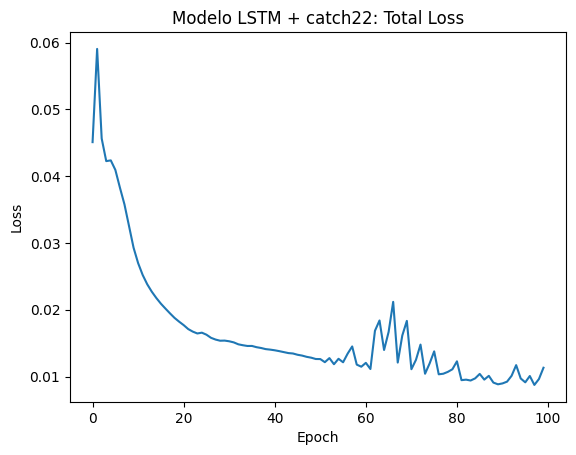

In [33]:
class LSTMCatch22Model(nn.Module):
    def __init__(self, hidden, n_feats):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc1 = nn.Linear(hidden + n_feats, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x, feats):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        combined = torch.cat([out, feats], dim=1)
        combined = self.relu(self.fc1(combined))
        return self.fc2(combined)


torch.manual_seed(42)

# Vector catch22 estandarizado de la serie Total (calculado en 2.4)
catch22_total = torch.tensor(matriz_std.loc["Total"].values, dtype=torch.float32)
N_FEATS = catch22_total.shape[0]

catch22_train_batch = catch22_total.unsqueeze(0).repeat(X_train.shape[0], 1)
catch22_test_batch = catch22_total.unsqueeze(0).repeat(X_test.shape[0], 1)

train_loader3 = DataLoader(
    TensorDataset(X_train, catch22_train_batch, y_train),
    batch_size=8,
    shuffle=False
)

model3 = LSTMCatch22Model(hidden=64, n_feats=N_FEATS)
criterion3 = nn.MSELoss()
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

losses3 = []
for epoch in range(100):
    model3.train()
    epoch_loss = 0
    for Xb, Fb, yb in train_loader3:
        optimizer3.zero_grad()
        pred = model3(Xb, Fb)
        loss = criterion3(pred, yb)
        loss.backward()
        optimizer3.step()
        epoch_loss += loss.item()
    losses3.append(epoch_loss / len(train_loader3))

plt.plot(losses3)
plt.title("Modelo LSTM + catch22: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [34]:
model3.eval()
with torch.no_grad():
    pred3 = model3(X_test, catch22_test_batch).numpy()

pred3_inv = scaler.inverse_transform(pred3)

rmse3, mae3, mape3 = evaluate(real, pred3_inv)

comparison_catch22 = pd.DataFrame({
    "Modelo": ["LSTM 2 (sin catch22)", "LSTM + catch22"],
    "Serie": ["Total", "Total"],
    "RMSE": [rmse2, rmse3],
    "MAE": [mae2, mae3],
    "MAPE": [mape2, mape3],
})
comparison_catch22

,Modelo,Serie,RMSE,MAE,MAPE
0,LSTM 2 (sin catch22),Total,58218.257480,45795.148438,15.149678
1,LSTM + catch22,Total,78478.683781,59574.550781,18.512276


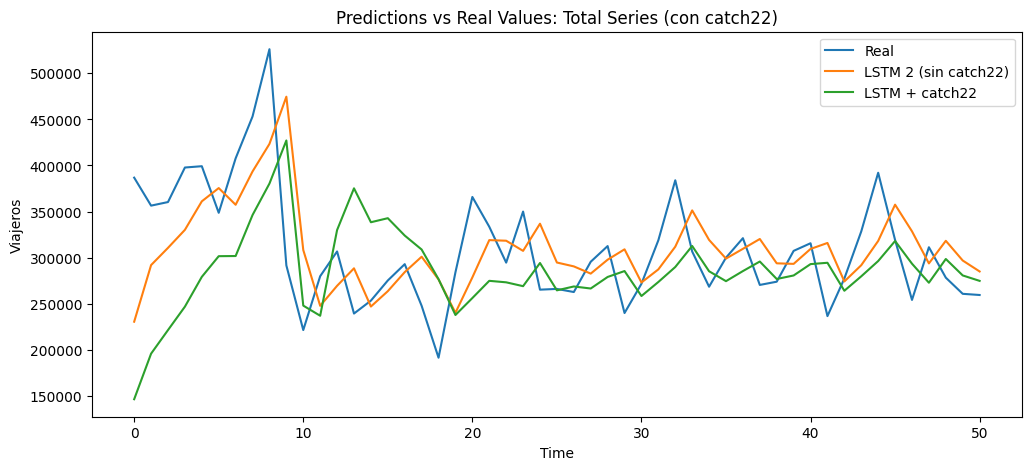

In [35]:
plt.figure(figsize=(12, 5))
plt.title("Predictions vs Real Values: Total Series (con catch22)")
plt.xlabel("Time")
plt.ylabel("Viajeros")
plt.plot(real, label="Real")
plt.plot(pred2, label="LSTM 2 (sin catch22)")
plt.plot(pred3_inv, label="LSTM + catch22")
plt.legend()
plt.show()

**Discusión:**

El modelo con características catch22 **no mejoró** al mejor modelo de la sección 1: el RMSE aumenta de 58,218 a 78,479 (+35 %) y el MAPE pasa de 15.1 % a 18.5 %.

El resultado es esperable por la forma en que entra la información. El vector catch22 describe a la serie **completa**, no a cada ventana: como el modelo se entrena sobre una sola serie (Total), esas 22 características toman **el mismo valor en las 135 ventanas de entrenamiento**. Al ser constantes, no aportan ninguna señal que permita distinguir una ventana de otra y en la práctica funcionan como un sesgo adicional. Lo que sí agregan son 22 entradas más y una capa densa intermedia, es decir, más parámetros que ajustar con la misma cantidad de datos. El efecto neto es mayor capacidad sin información nueva, lo que favorece el sobreajuste. A esto se suma que los modelos 1 y 2 se entrenaron sin fijar semilla, por lo que parte del margen corresponde a variabilidad entre corridas; aun así, la dirección del resultado es clara.

Donde estas características sí resultarían útiles es en un esquema **multiserie**. Si la red se entrenara con las siete series a la vez, el vector catch22 dejaría de ser constante y le permitiría identificar con qué tipo de serie está trabajando —memoria larga o corta, estable o volátil— y ajustar su comportamiento en consecuencia. Ese es el uso natural de catch22 como entrada de un modelo y queda como la extensión pendiente del ejercicio.